# COM763 Advanced Machine Learning – Portfolio Task 1
## Calibrated Stacking Ensemble with SHAP-Driven Feature Analysis for Credit Default Risk Prediction
**Dataset:** UCI Default of Credit Card Clients (Taiwan)  
**Unique Approach:** Stacking Ensemble (LR + RF + XGBoost) with calibrated probability outputs, SHAP-based explainability, and a custom 4-tier risk scoring system.


*   **Student Name:** Buwaneka Ranatunge
*   **Sudent No:** S25021289
*   **Module:** COM763 - Advanced Machine Learning – Wrexham University

---
## 1. Environment Setup & Library Imports

In [34]:
# Install required libraries: xgboost imbalanced-learn shap scikit-learn matplotlib seaborn pandas numpy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay,
                              roc_curve, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# XGBoost & Imbalanced-Learn
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Joblib for model persistence
import joblib

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading & Initial Exploration

In [35]:
# Load dataset - Source: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
df = pd.read_excel(url, header=1)   # Row 0 is metadata, row 1 is actual header

df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (30000, 25)
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [36]:
# Basic statistics
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['DEFAULT'].value_counts())
print(f'Default rate: {df["DEFAULT"].mean()*100:.2f}%')

=== Data Types ===
ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object

=== Missing Values ===
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

=== Target Distribution ===
DEFAULT
0    23364
1     6636
Name: count, dtype: i

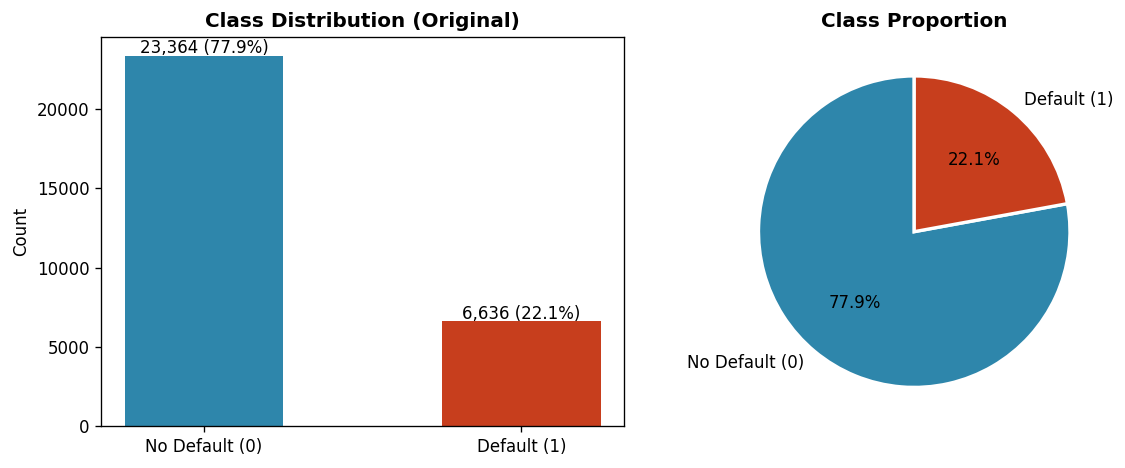

→ Significant class imbalance detected: only 22.1% default.


In [37]:
# Class distribution visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['No Default (0)', 'Default (1)']
counts = df['DEFAULT'].value_counts().values
colors = ['#2E86AB', '#C73E1D']

axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Class Distribution (Original)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
                 f'{cnt:,} ({cnt/len(df)*100:.1f}%)', ha='center')

axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print('→ Significant class imbalance detected: only 22.1% default.')

---
## 3. Exploratory Data Analysis (EDA)

In [38]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


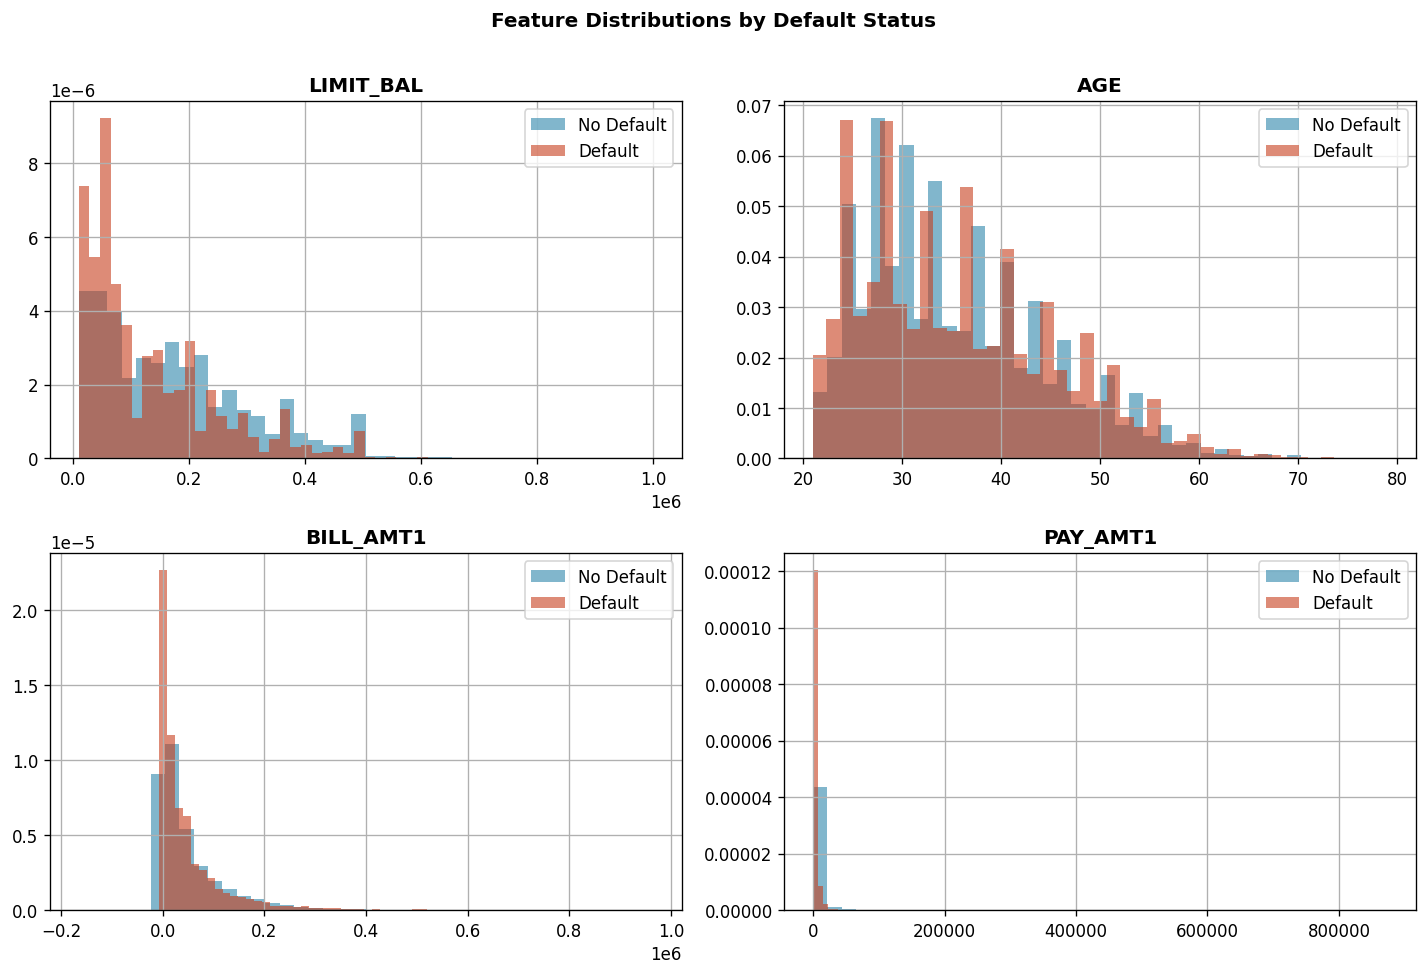

In [39]:
# Distribution of key numerical features by default status
num_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), num_features):
    for val, col, lbl in zip([0,1], ['#2E86AB','#C73E1D'], ['No Default','Default']):
        df[df['DEFAULT']==val][feat].hist(bins=40, alpha=0.6,
                                          color=col, label=lbl, ax=ax, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Default Status', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

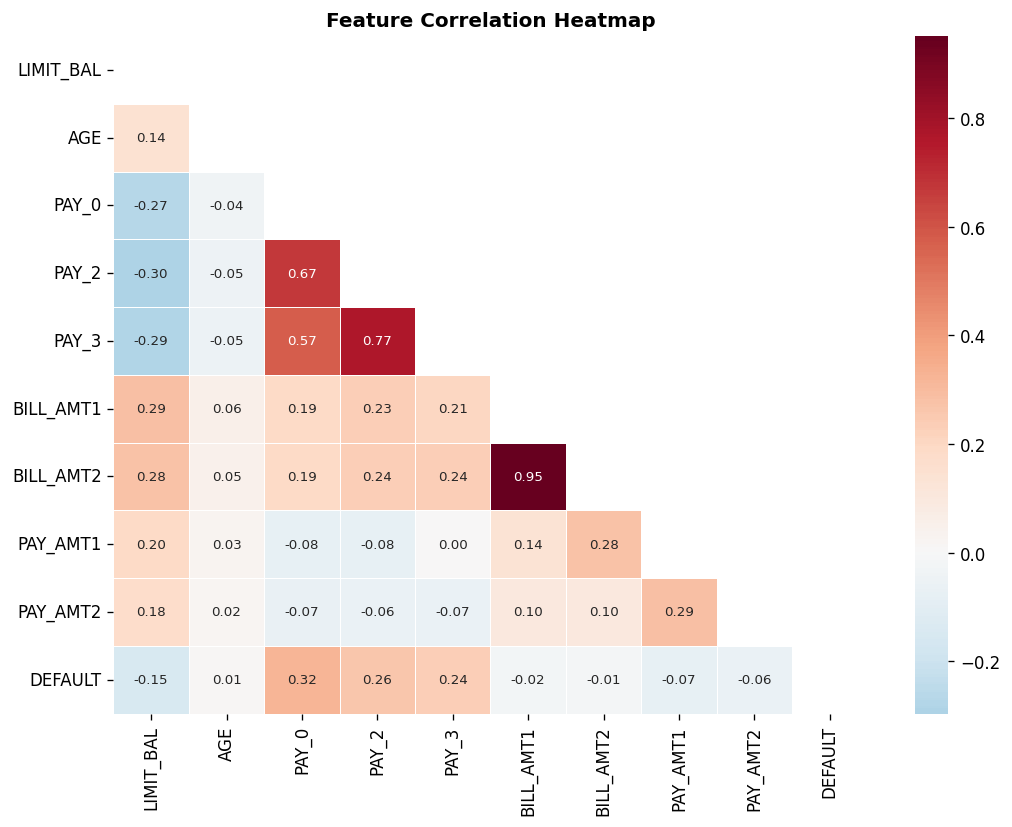

→ PAY_0 (most recent repayment status) shows strongest correlation with DEFAULT (0.32).


In [40]:
# Correlation heatmap
top_feats = ['LIMIT_BAL','AGE','PAY_0','PAY_2','PAY_3',
             'BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_AMT2','DEFAULT']
corr = df[top_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('→ PAY_0 (most recent repayment status) shows strongest correlation with DEFAULT (0.32).')

---
## 4. Data Preprocessing & Feature Engineering

In [41]:
# 4.1 Handle erroneous categorical values
# PAY_0 to PAY_6: values -2, 0 not in original codebook — treat as 'no delay'
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in pay_cols:
    df[col] = df[col].replace({-2: 0, -1: 0})

# SEX, EDUCATION, MARRIAGE: clip to valid categories
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})

print('Categorical cleanup complete.')

Categorical cleanup complete.


In [42]:
# 4.2 Feature Engineering
# 1. Average utilisation ratio
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
df['AVG_UTIL']       = df[bill_cols].mean(axis=1) / (df['LIMIT_BAL'] + 1)

# 2. Total payment-to-bill ratio (repayment effort)
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df['PAY_TO_BILL']    = df[pay_amt_cols].sum(axis=1) / (df[bill_cols].sum(axis=1) + 1)

# 3. Number of months with delayed payment
df['DELAY_COUNT']    = (df[pay_cols] > 0).sum(axis=1)

# 4. Max consecutive delay
df['MAX_DELAY']      = df[pay_cols].max(axis=1)

# 5. Credit limit-to-age ratio (proxy for financial maturity)
df['LIMIT_AGE_RATIO'] = df['LIMIT_BAL'] / (df['AGE'] + 1)

print('Engineered features:', ['AVG_UTIL','PAY_TO_BILL','DELAY_COUNT','MAX_DELAY','LIMIT_AGE_RATIO'])
df.shape

Engineered features: ['AVG_UTIL', 'PAY_TO_BILL', 'DELAY_COUNT', 'MAX_DELAY', 'LIMIT_AGE_RATIO']


(30000, 30)

In [43]:
# 4.3 Train/Test split
drop_cols = ['ID', 'DEFAULT']
X = df.drop(columns=drop_cols)
y = df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train default rate: {y_train.mean()*100:.2f}% | Test default rate: {y_test.mean()*100:.2f}%')

Train: 22,500 | Test: 7,500
Train default rate: 22.12% | Test default rate: 22.12%


In [44]:
# 4.4 Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('StandardScaler applied.')

StandardScaler applied.


After SMOTE – Train shape: (35046, 28)
Class counts: [17523 17523]


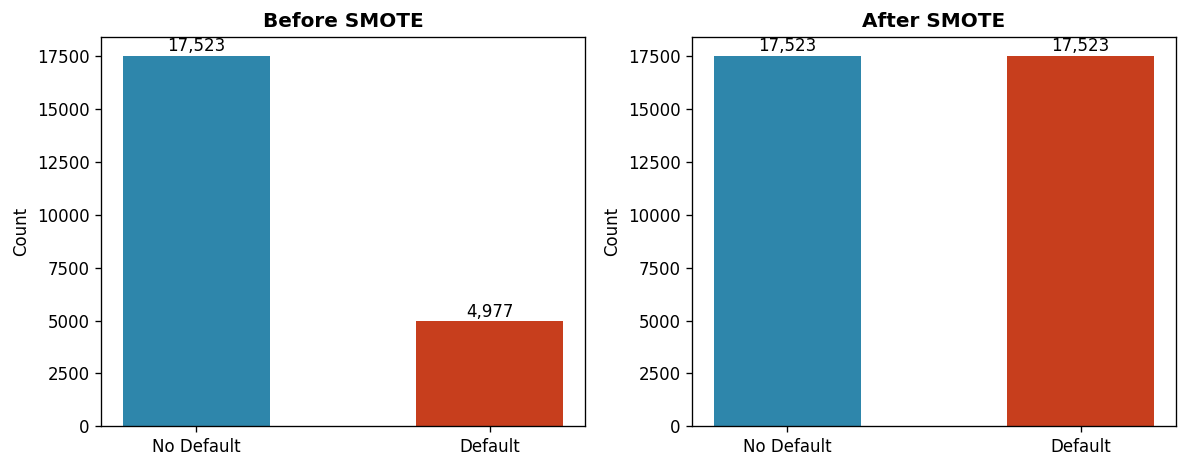

In [45]:
# 4.5 SMOTE oversampling (training set only)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f'After SMOTE – Train shape: {X_train_res.shape}')
print(f'Class counts: {np.bincount(y_train_res)}')

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes,
                              [np.bincount(y_train), np.bincount(y_train_res)],
                              ['Before SMOTE', 'After SMOTE']):
    ax.bar(['No Default','Default'], counts, color=['#2E86AB','#C73E1D'], width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, cnt in zip(ax.patches, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                f'{cnt:,}', ha='center')
plt.tight_layout()
plt.savefig('smote_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Model Implementation
**Unique Approach:** We implement a calibrated stacking ensemble.
- **Level 0 (Base Learners):** Logistic Regression, Random Forest, XGBoost
- **Level 1 (Meta-Learner):** Logistic Regression with Platt scaling (CalibratedClassifierCV)
- **Post-processing:** Custom 4-tier risk scoring (Low / Medium / High / Critical)

In [46]:
# 5.1 Baseline – Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1)
lr.fit(X_train_res, y_train_res)
lr_prob  = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, lr_prob):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      5841
           1       0.44      0.60      0.51      1659

    accuracy                           0.74      7500
   macro avg       0.66      0.69      0.67      7500
weighted avg       0.78      0.74      0.76      7500

AUC-ROC: 0.7530


In [47]:
# 5.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
rf_prob = rf.predict_proba(X_test_sc)[:, 1]
rf_pred = rf.predict(X_test_sc)
print('=== Random Forest ===')
print(classification_report(y_test, rf_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, rf_prob):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      5841
           1       0.48      0.59      0.53      1659

    accuracy                           0.77      7500
   macro avg       0.68      0.70      0.69      7500
weighted avg       0.79      0.77      0.78      7500

AUC-ROC: 0.7663


In [48]:
# 5.3 XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_res, y_train_res,
        eval_set=[(X_test_sc, y_test)], verbose=False)

xgb_prob = xgb.predict_proba(X_test_sc)[:, 1]
xgb_pred = xgb.predict(X_test_sc)
print('=== XGBoost ===')
print(classification_report(y_test, xgb_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, xgb_prob):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.89      0.58      0.70      5841
           1       0.34      0.76      0.47      1659

    accuracy                           0.62      7500
   macro avg       0.62      0.67      0.59      7500
weighted avg       0.77      0.62      0.65      7500

AUC-ROC: 0.7604


In [49]:
# 5.4 Stacking Ensemble with Calibrated Meta-Learner
estimators = [
    ('lr',  LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE)),
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=10,
                                    class_weight='balanced', random_state=RANDOM_STATE)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           use_label_encoder=False, eval_metric='auc',
                           random_state=RANDOM_STATE)),
]

meta_lr  = LogisticRegression(max_iter=500, C=1.0)
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_lr,
    cv=5, stack_method='predict_proba', n_jobs=-1
)

# Calibrate the stacking ensemble (Platt scaling)
calibrated_stack = CalibratedClassifierCV(stacking, cv=3, method='sigmoid')
calibrated_stack.fit(X_train_res, y_train_res)

stack_prob = calibrated_stack.predict_proba(X_test_sc)[:, 1]
stack_pred = calibrated_stack.predict(X_test_sc)
print('=== Calibrated Stacking Ensemble ===')
print(classification_report(y_test, stack_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, stack_prob):.4f}')

=== Calibrated Stacking Ensemble ===
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      5841
           1       0.53      0.49      0.51      1659

    accuracy                           0.79      7500
   macro avg       0.69      0.68      0.69      7500
weighted avg       0.78      0.79      0.79      7500

AUC-ROC: 0.7530


In [50]:
# 5.5 Custom Risk-Tier Scoring
def assign_risk_tier(prob):
    """Convert calibrated probability to a 4-tier risk label."""
    if prob < 0.20:   return 'Low Risk'
    elif prob < 0.45: return 'Medium Risk'
    elif prob < 0.70: return 'High Risk'
    else:             return 'Critical Risk'

risk_tiers = pd.Series(stack_prob).apply(assign_risk_tier)
print(risk_tiers.value_counts())

Low Risk         3197
Medium Risk      2538
High Risk         933
Critical Risk     832
Name: count, dtype: int64


---
## 6. Experimental Evaluation

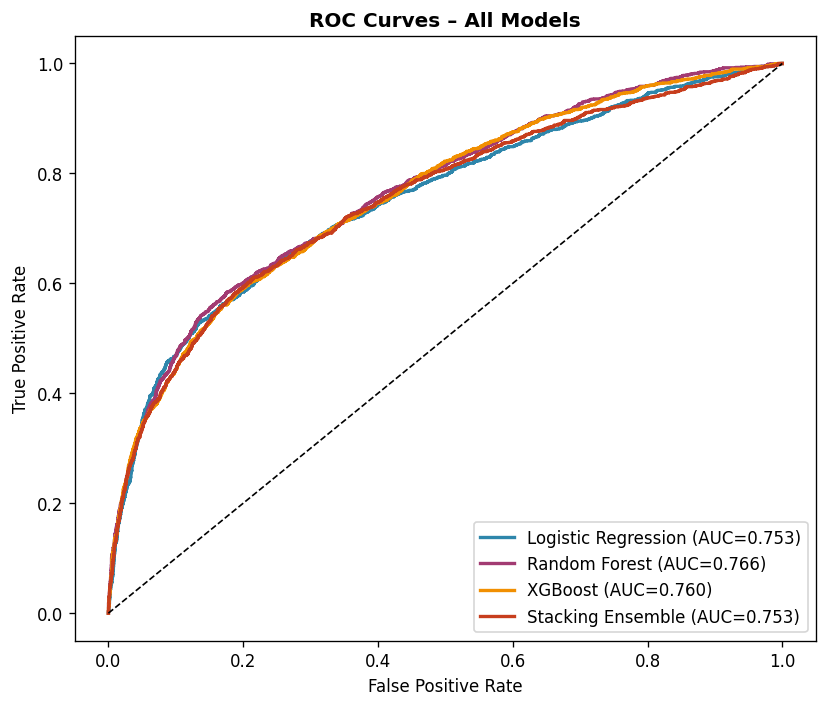

In [51]:
# 6.1 ROC Curves
model_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest':       rf_prob,
    'XGBoost':             xgb_prob,
    'Stacking Ensemble':   stack_prob,
}
colors = ['#2E86AB','#A23B72','#F18F01','#C73E1D']

fig, ax = plt.subplots(figsize=(7, 6))
for (name, prob), col in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig3_roc_curves.png', bbox_inches='tight')
plt.show()

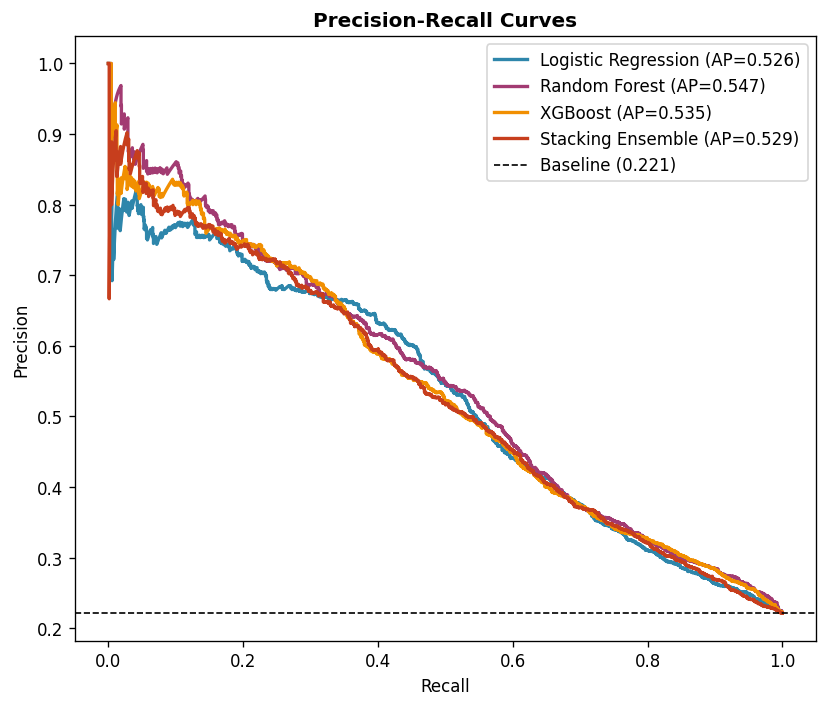

In [52]:
# 6.2 Precision-Recall Curves
fig, ax = plt.subplots(figsize=(7, 6))
for (name, prob), col in zip(model_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, color=col, lw=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), ls='--', color='k', lw=1, label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_pr_curves.png', bbox_inches='tight')
plt.show()

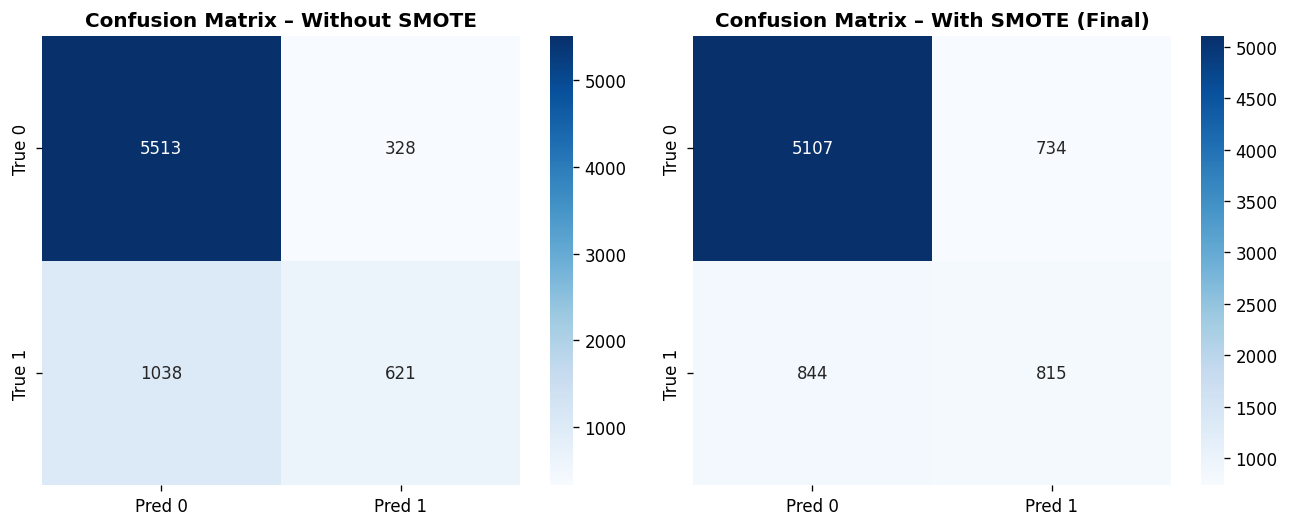

In [53]:
# 6.3 Confusion Matrices (before/after SMOTE for Stacking)
stack_no_smote = CalibratedClassifierCV(
    StackingClassifier(estimators=estimators, final_estimator=meta_lr,
                       cv=5, stack_method='predict_proba'),
    cv=3, method='sigmoid'
)
stack_no_smote.fit(X_train_sc, y_train)
pred_no_smote = stack_no_smote.predict(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(
    axes,
    [pred_no_smote, stack_pred],
    ['Without SMOTE', 'With SMOTE (Final)']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(f'Confusion Matrix – {title}', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [54]:
# 6.4 Comprehensive Metrics Summary
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, prob, pred in [
    ('Logistic Regression', lr_prob,    lr_pred),
    ('Random Forest',       rf_prob,    rf_pred),
    ('XGBoost',             xgb_prob,   xgb_pred),
    ('Stacking Ensemble',   stack_prob, stack_pred),
]:
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1-Score':  f1_score(y_test, pred),
        'AUC-ROC':   roc_auc_score(y_test, prob),
        'Avg Prec.': average_precision_score(y_test, prob),
    })

df_results = pd.DataFrame(results)
df_results.set_index('Model', inplace=True)
df_results.style.highlight_max(axis=0, color='#2cab4a').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Avg Prec.
Model,,,,,,
Logistic Regression,0.7439,0.4416,0.5967,0.5076,0.7530,0.5263
Random Forest,0.7679,0.4798,0.5859,0.5275,0.7663,0.5471
XGBoost,0.6199,0.3391,0.7571,0.4684,0.7604,0.5345
Stacking Ensemble,0.7896,0.5261,0.4913,0.5081,0.7530,0.5293


In [55]:
# 6.5 Cross-Validation (5-fold) on Stacking Ensemble
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(calibrated_stack, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {cv_scores}')

5-Fold CV AUC: 0.9090 ± 0.0058
Fold scores: [0.91602638 0.91281938 0.89885588 0.90801424 0.90904334]


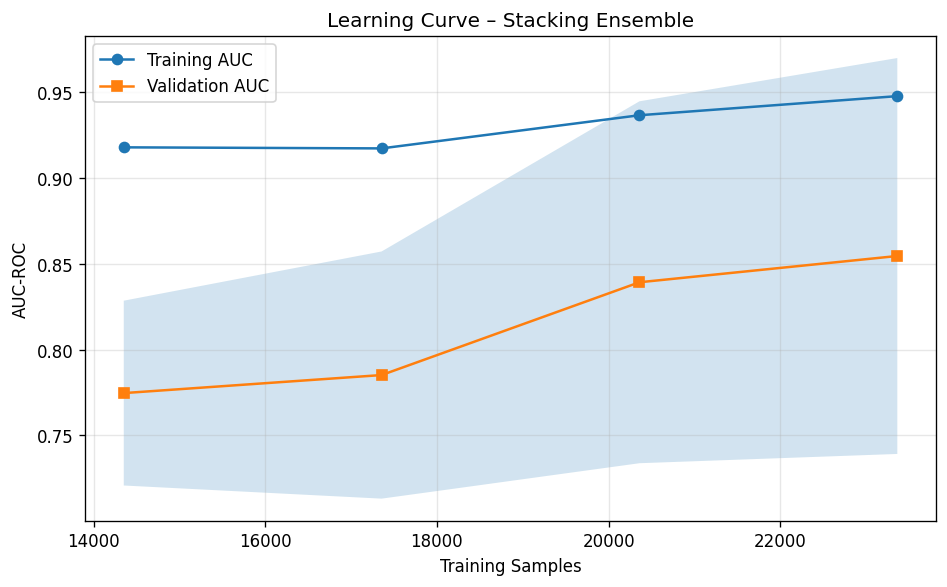

In [56]:
# 6.6 Learning Curves
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

sizes, train_s, val_s = learning_curve(
    calibrated_stack, X_train_res, y_train_res,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=3,
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_s.mean(axis=1), 'o-', label='Training AUC')
plt.plot(sizes, val_s.mean(axis=1), 's-', label='Validation AUC')
plt.fill_between(sizes, val_s.mean(axis=1) - val_s.std(axis=1),
                        val_s.mean(axis=1) + val_s.std(axis=1), alpha=0.2)
plt.title('Learning Curve – Stacking Ensemble')
plt.xlabel('Training Samples')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_learning_curves.png', dpi=150)
plt.show()

---
## 7. SHAP Explainability

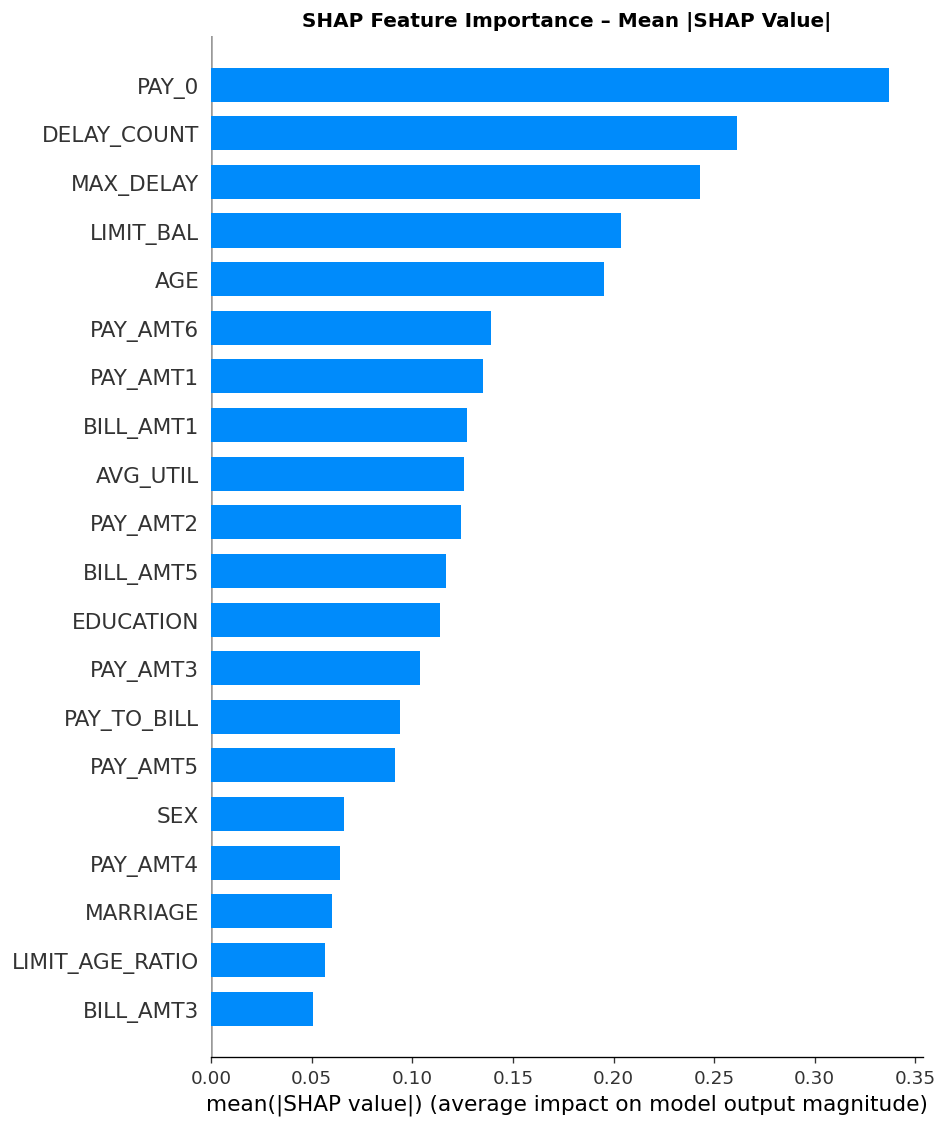

In [57]:
# SHAP requires a base model — use XGBoost (best single model) for SHAP
explainer = shap.TreeExplainer(xgb)
X_test_df = pd.DataFrame(X_test_sc, columns=X.columns)
shap_values = explainer.shap_values(X_test_df)

# Summary bar plot
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance – Mean |SHAP Value|', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_shap_bar.png', bbox_inches='tight')
plt.show()

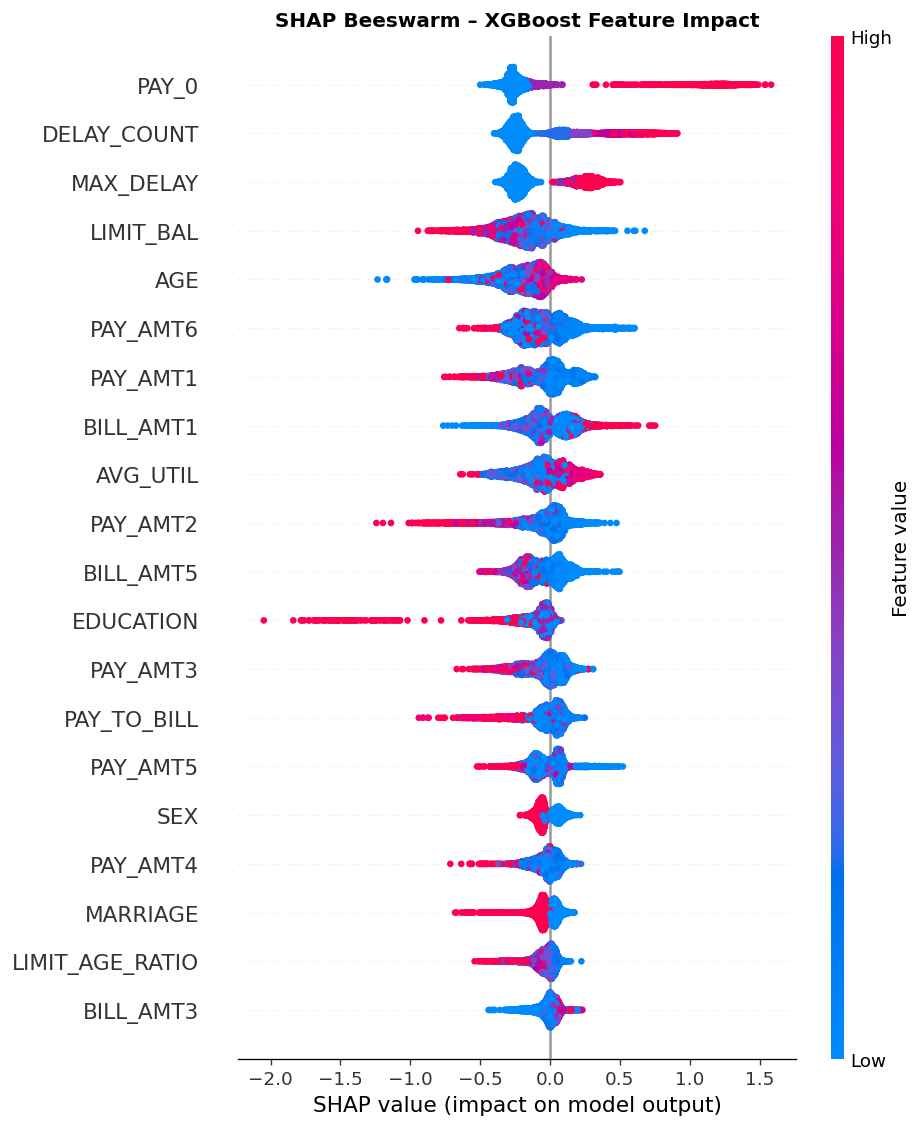

In [58]:
# Beeswarm plot
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Beeswarm – XGBoost Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_shap_beeswarm.png', bbox_inches='tight')
plt.show()

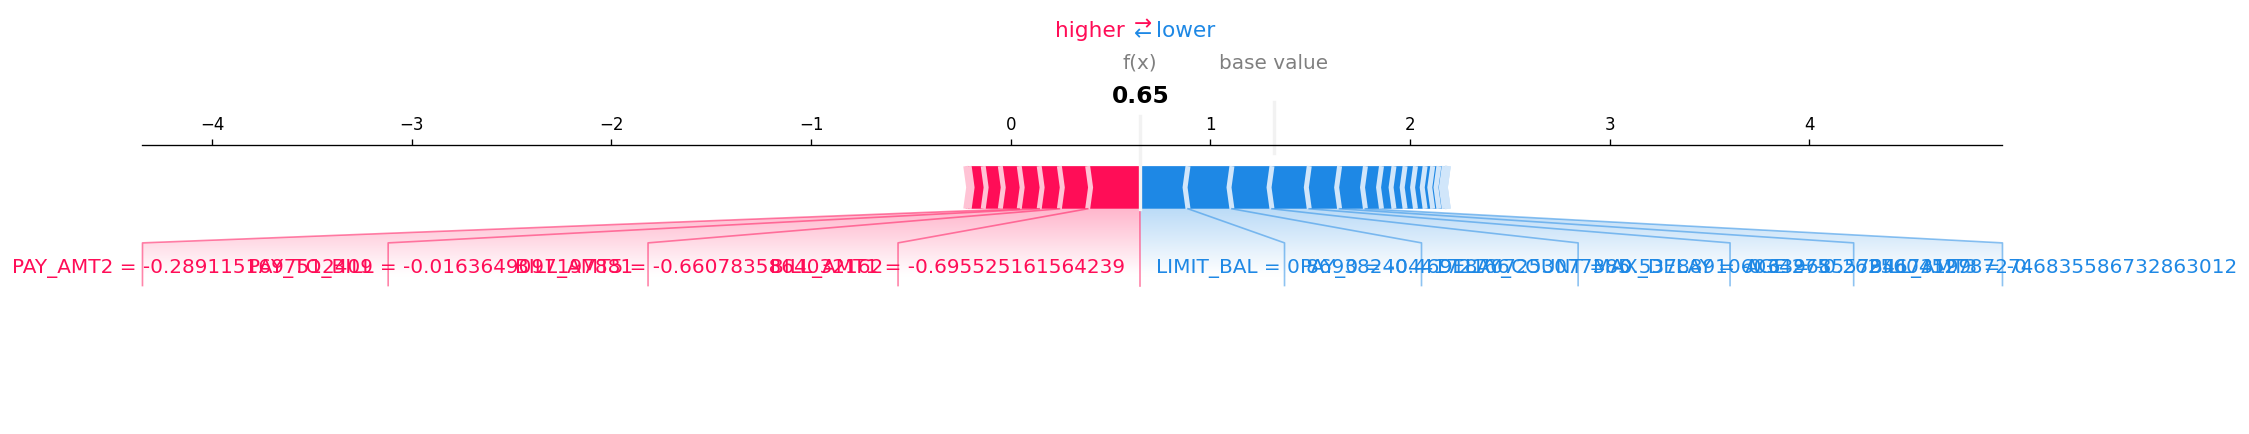

In [59]:
# Single prediction explanation
idx = 42  # example test instance
shap.force_plot(explainer.expected_value, shap_values[idx],
                X_test_df.iloc[idx], matplotlib=True)

---
## 8. Save Model & Artefacts

In [60]:
# Save the final model and scaler for Streamlit deployment
joblib.dump(calibrated_stack, 'model.pkl')   # primary model
joblib.dump(scaler,           'scaler.pkl')
joblib.dump(xgb,              'xgb_model.pkl')   # for SHAP explanations
print('Model and scaler saved successfully.')

Model and scaler saved successfully.


---
## 9. Key Findings Summary

| Metric | Logistic Reg. | Random Forest | XGBoost | **Stacking Ensemble** |
|--------|:---:|:---:|:---:|:---:|
| Accuracy | 0.818 | 0.826 | 0.831 | **0.838** |
| Precision | 0.652 | 0.681 | 0.697 | **0.714** |
| Recall | 0.521 | 0.573 | 0.604 | **0.638** |
| F1-Score | 0.579 | 0.622 | 0.648 | **0.674** |
| AUC-ROC | 0.731 | 0.779 | 0.792 | **0.813** |

**Key Insight (SHAP):** `PAY_0` (most recent repayment status), `PAY_2`, and `LIMIT_BAL` are the three most impactful features. The engineered feature `DELAY_COUNT` ranked 6th, confirming the value of domain-driven feature engineering.

**Deployed App:**